<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> 一书（作者 <a href="https://sebastianraschka.com">Sebastian Raschka</a>）的补充代码<br>
<br>代码仓库：<a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第 6 章：用于文本分类的微调（Finetuning for Text Classification）

In [87]:
from importlib.metadata import PackageNotFoundError, version


def get_package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        if package_name == "tensorflow":
            return version("tensorflow-cpu")
        raise


pkgs = ["matplotlib",  # Plotting library
        "numpy",       # PyTorch & TensorFlow dependency
        "tiktoken",    # Tokenizer
        "torch",       # Deep learning library
        "tensorflow",  # For OpenAI's pretrained weights
        "pandas"       # Dataset loading
       ]
for p in pkgs:
    print(f"{p} version: {get_package_version(p)}")

matplotlib version: 3.11.0
numpy version: 1.26.4
tiktoken version: 0.13.0
torch version: 2.7.1+cu118
tensorflow version: 2.21.0
pandas version: 2.0.3


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/01.webp" width=1000px>

&nbsp;
### 6.1 微调的不同类别（Different categories of finetuning）

- 本节没有代码。

- 微调语言模型最常见的方式是 instruction-finetuning（指令微调）和 classification finetuning（分类微调）。
- 下图展示的 instruction-finetuning 是下一章的主题。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/02.webp" width=1000px>

- 本章主题 classification finetuning，如果你有机器学习背景，可能已经很熟悉这个流程；例如，它类似于训练卷积网络来分类手写数字。
- 在 classification finetuning 中，模型可以输出固定数量的 class labels（例如 "spam" 和 "not spam"）。
- classification-finetuned model 只能预测训练时见过的类别（例如 "spam" 或 "not spam"），而 instruction-finetuned model 通常能执行许多任务。
- 可以把 classification-finetuned model 看成一种非常专门化的模型；实践中，创建一个 specialized model 通常比创建一个能在许多任务上表现良好的 generalist model 更容易。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/03.webp" width=1000px>

&nbsp;
### 6.2 准备数据集（Preparing the dataset）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/04.webp" width=1000px>

- 本节准备用于 classification finetuning 的数据集。
- 我们使用一个由 spam 和 non-spam 文本消息组成的数据集，微调 LLM 来对它们分类。
- 首先，下载并解压数据集。

In [88]:
import requests
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    # stream=True 表示分块下载，适合下载较大文件。
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")


try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)



# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

"""
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Downloading the file
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"Primary URL failed: {e}. Trying backup URL...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
"""

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


'\nimport urllib.request\nimport zipfile\nimport os\nfrom pathlib import Path\n\nurl = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"\nzip_path = "sms_spam_collection.zip"\nextracted_path = "sms_spam_collection"\ndata_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"\n\ndef download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):\n    if data_file_path.exists():\n        print(f"{data_file_path} already exists. Skipping download and extraction.")\n        return\n\n    # Downloading the file\n    with urllib.request.urlopen(url) as response:\n        with open(zip_path, "wb") as out_file:\n            out_file.write(response.read())\n\n    # Unzipping the file\n    with zipfile.ZipFile(zip_path, "r") as zip_ref:\n        zip_ref.extractall(extracted_path)\n\n    # Add .tsv file extension\n    original_file_path = Path(extracted_path) / "SMSSpamCollection"\n    os.rename(original_file_path, data_file_path)\n    print(f"File downloade

- 数据集保存为 tab-separated text file，可以加载到 pandas DataFrame 中。

In [89]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


- 检查 class distribution 时可以看到，数据中 "ham"（即 "not spam"）比 "spam" 出现得更频繁。

In [90]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


- 为简单起见，也因为教学目的下我们更希望使用小数据集（这样能更快地微调 LLM），我们对数据集进行 subsample（undersample），使每个类别都包含 747 个样本。
- （除了 undersampling，还有许多其他处理 class imbalance 的方法，但这超出了 LLM 书籍的范围；可以在 [`imbalanced-learn` user guide](https://imbalanced-learn.org/stable/user_guide.html) 中找到示例和更多信息。）

In [91]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


- 接下来，把字符串类别标签 "ham" 和 "spam" 改成整数类别标签 0 和 1：

In [92]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})    

In [93]:
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


- 现在定义一个函数，随机把数据集划分为 training、validation 和 test subsets。

In [94]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

&nbsp;
### 6.3 创建 data loaders（Creating data loaders）

- 注意，文本消息长度不同；如果想把多个 training examples 合并到一个 batch 中，必须采用下面两种方式之一：
  1. 把所有消息截断到数据集或 batch 中最短消息的长度
  2. 把所有消息 padding 到数据集或 batch 中最长消息的长度

- 我们选择方案 2，把所有消息 padding 到数据集中最长消息的长度。
- 为此，我们使用 `<|endoftext|>` 作为 padding token，正如第 2 章中讨论的那样。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/06.webp" width=500px>

In [95]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


- 下面的 `SpamDataset` class 会识别 training dataset 中最长的序列，并向其他序列添加 padding token，使它们匹配该序列长度。

In [96]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # 方向 A：在 SpamDataset 里自动兜底
        if self.data["Label"].dtype == object:
            self.data["Label"] = self.data["Label"].map({"ham": 0, "spam": 1})

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # Note: A more pythonic version to implement this method
        # is the following, which is also used in the next chapter:
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [97]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)
train_dataset.data

120


,Label,Text
0,0,Dude how do you like the buff wind.
1,0,Tessy..pls do me a favor. Pls convey my birthd...
2,1,Reminder: You have not downloaded the content ...
3,1,Got what it takes 2 take part in the WRC Rally...
4,1,"Shop till u Drop, IS IT YOU, either 10K, 5K, £..."
...,...,...
1040,1,4mths half price Orange line rental & latest c...
1041,1,Thanks for the Vote. Now sing along with the s...
1042,1,IMPORTANT INFORMATION 4 ORANGE USER 0796XXXXXX...
1043,1,Urgent! call 09066612661 from landline. Your c...


- 我们也把 validation set 和 test set padding 到最长 training sequence 的长度。
- 注意，在 `SpamDataset` 代码中，validation 和 test set 里长于最长 training example 的样本会通过 `encoded_text[:self.max_length]` 被截断。
- 这个行为完全是可选的；如果在 validation set 和 test set 中都设置 `max_length=None`，也可以正常工作。

In [98]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

- 接下来，使用这个 dataset 实例化 data loaders；这与前几章创建 data loaders 的方式类似。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/07.webp" width=1000px>

In [99]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

- 作为验证步骤，我们遍历 data loaders，确保每个 batch 包含 8 个 training examples，并且每个 training example 由 120 个 tokens 组成。

In [100]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


- 最后，打印每个 dataset 中的 batch 总数。

In [101]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


&nbsp;
### 6.4 使用预训练权重初始化模型（Initializing a model with pretrained weights）

- 本节会初始化上一章使用过的 pretrained model。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/08.webp" width=1000px>

In [102]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

In [103]:
from pathlib import Path

import requests
import torch

from previous_chapters import GPTModel
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel

weight_files = {
    "gpt2-small (124M)": "gpt2-small-124M.pth",
    "gpt2-medium (355M)": "gpt2-medium-355M.pth",
    "gpt2-large (774M)": "gpt2-large-774M.pth",
    "gpt2-xl (1558M)": "gpt2-xl-1558M.pth",
}

weights_dir = Path("../../ch05/02_alternative_weight_loading")
weights_dir.mkdir(parents=True, exist_ok=True)
weight_file = weights_dir / weight_files[CHOOSE_MODEL]

if not weight_file.exists():
    url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{weight_file.name}"
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    weight_file.write_bytes(response.content)
    print(f"Downloaded to {weight_file}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(weight_file, map_location="cpu", weights_only=True))
model.to(device)
model.eval();

Device: cuda


- 为了确保模型正确加载，先再次检查它是否能生成连贯文本。

In [104]:
from previous_chapters import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

# Alternatively:
# from llms_from_scratch.ch05 import (
#    generate_text_simple,
#    text_to_token_ids,
#    token_ids_to_text
# )


text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer).to(device),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


- 在把模型作为 classifier 微调之前，先看看它是否已经能通过 prompting 对 spam messages 进行分类。

In [105]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer).to(device),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


- 可以看到，模型并不擅长 follow instructions。
- 这是预期中的，因为它只经过了 pretraining，还没有进行 instruction-finetuning（instruction finetuning 会在下一章介绍）。

&nbsp;
### 6.5 添加分类头（Adding a classification head）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/09.webp" width=500px>

- 本节会修改 pretrained LLM，让它为 classification finetuning 做好准备。
- 先看一下 model architecture。

In [106]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

- 上面可以看到我们在第 4 章实现的 architecture，已经清晰地展开显示。
- 目标是替换并微调 output layer。
- 为此，我们首先 freeze model，也就是让所有 layers 变成 non-trainable。

In [107]:
for param in model.parameters():
    param.requires_grad = False

- 然后替换 output layer（`model.out_head`）；它原本会把 layer inputs 映射到 50,257 个维度（vocabulary size）。
- 由于我们要为 binary classification（预测 2 个类别："spam" 和 "not spam"）微调模型，可以按下面方式替换 output layer；它默认是 trainable。
- 注意，我们使用 `BASE_CONFIG["emb_dim"]`（在 `"gpt2-small (124M)"` model 中等于 768），这样下面的代码更通用。

In [108]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes
).to(device)

- 技术上，只训练 output layer 已经足够。
- 不过，我在 [Finetuning Large Language Models](https://magazine.sebastianraschka.com/p/finetuning-large-language-models) 中发现，实验表明微调额外 layers 可以明显提升性能。
- 因此，我们也让最后一个 transformer block 以及连接最后一个 transformer block 和 output layer 的 final `LayerNorm` module 变为 trainable。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/10.webp" width=500px>

In [109]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

- 仍然可以像前几章一样使用这个模型。
- 例如，给它输入一些文本。

In [110]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0).to(device)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]], device='cuda:0')
Inputs dimensions: torch.Size([1, 4])


- 与前几章不同的是，现在它有 2 个输出维度，而不是 50,257 个。

In [111]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]], device='cuda:0')
Outputs dimensions: torch.Size([1, 4, 2])


- 如前几章所述，对于每个 input token，都会有一个 output vector。
- 因为我们给模型输入了一个包含 4 个 input tokens 的文本样本，所以上面的输出包含 4 个二维 output vectors。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/11.webp" width=1000px>

- 第 3 章讨论了 attention mechanism，它把每个 input token 与其他 input tokens 连接起来。
- 第 3 章还介绍了 GPT-like models 中使用的 causal attention mask；这个 causal mask 让当前 token 只能 attend 到当前和之前的 token positions。
- 基于这种 causal attention mechanism，第 4 个（最后一个）token 包含所有 tokens 中最多的信息，因为只有它包含了关于其他所有 tokens 的信息。
- 因此，我们尤其关注这个 last token，并将围绕它对 spam classification task 进行微调。

In [133]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]], device='cuda:0')


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/12.webp" width=200px>

&nbsp;
### 6.6 计算分类损失和准确率（Calculating classification loss and accuracy）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/13.webp" width=1000px>

- 在解释 loss calculation 之前，先简单看一下模型输出如何转换为 class labels。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/14.webp" width=1000px>

In [113]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]], device='cuda:0')


- 与第 5 章类似，我们通过 `softmax` function 把 outputs（logits）转换为 probability scores，然后通过 `argmax` function 得到最大概率值所在的 index position。

In [135]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas).item()
print("Class label:", label)

Class label: 1


- 注意，如第 5 章所解释，这里 softmax function 是可选的，因为最大的 outputs 对应最大的 probability scores。

In [136]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


- 可以应用这个概念来计算所谓的 classification accuracy，它表示给定 dataset 中正确预测所占的百分比。
- 为了计算 classification accuracy，可以把前面基于 `argmax` 的预测代码应用到 dataset 中所有 examples，并按如下方式计算正确预测比例：

In [137]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

- 现在使用这个函数计算不同 datasets 上的 classification accuracies：

In [138]:
print("Device:", device)

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: cuda
Training accuracy: 95.00%
Validation accuracy: 98.75%
Test accuracy: 95.00%


- 可以看到，由于还没有微调模型，prediction accuracies 并不理想。

- 在开始 finetuning（/training）之前，首先需要定义训练期间要优化的 loss function。
- 目标是最大化模型的 spam classification accuracy；但是 classification accuracy 不是 differentiable function。
- 因此，我们改为最小化 cross-entropy loss，把它作为最大化 classification accuracy 的 proxy（关于这个主题，可以参考我免费课程 [Introduction to Deep Learning](https://sebastianraschka.com/blog/2021/dl-course.html#l08-multinomial-logistic-regression--softmax-regression) 的第 8 讲）。

- 这里的 `calc_loss_batch` function 与第 5 章相同，区别是我们只关心优化最后一个 token：`model(input_batch)[:, -1, :]`，而不是所有 tokens：`model(input_batch)`。

In [139]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

`calc_loss_loader` 与第 5 章完全相同。

In [140]:
# Same as in chapter 5
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- 使用 `calc_loss_loader`，在开始训练前计算初始 training、validation 和 test set losses。

In [141]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 0.073
Validation loss: 0.081
Test loss: 0.354


- 下一节会训练模型，以改善 loss values，并由此提升 classification accuracy。

&nbsp;
### 6.7 在监督数据上微调模型（Finetuning on supervised data）

- 本节会定义并使用 training function 来提升模型的 classification accuracy。
- 下面的 `train_classifier_simple` function 实际上与第 5 章用于 pretraining model 的 `train_model_simple` function 基本相同。
- 只有两个区别：
  1. 现在跟踪已见过的 training examples 数量（`examples_seen`），而不是已见过的 tokens 数量。
  2. 每个 epoch 后计算 accuracy，而不是每个 epoch 后打印 sample text。

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/15.webp" width=1000px>

In [144]:
# Overall the same as `train_model_simple` in chapter 5
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

- `train_classifier_simple` 中使用的 `evaluate_model` function 与第 5 章中使用的函数相同。

In [145]:
# Same as chapter 5
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

- 训练在 M3 MacBook Air 笔记本上大约需要 5 分钟，在 V100 或 A100 GPU 上不到半分钟。

In [123]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.153, Val loss 2.392
Ep 1 (Step 000050): Train loss 0.617, Val loss 0.637
Ep 1 (Step 000100): Train loss 0.523, Val loss 0.557
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.561, Val loss 0.489
Ep 2 (Step 000200): Train loss 0.419, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.409, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.333, Val loss 0.320
Ep 3 (Step 000350): Train loss 0.340, Val loss 0.306
Training accuracy: 90.00% | Validation accuracy: 90.00%
Ep 4 (Step 000400): Train loss 0.136, Val loss 0.200
Ep 4 (Step 000450): Train loss 0.153, Val loss 0.132
Ep 4 (Step 000500): Train loss 0.222, Val loss 0.137
Training accuracy: 100.00% | Validation accuracy: 97.50%
Ep 5 (Step 000550): Train loss 0.207, Val loss 0.143
Ep 5 (Step 000600): Train loss 0.083, Val loss 0.074
Training accuracy: 100.00% | Validation accuracy: 97.50%
Training completed in 0.84 mi

- 与第 5 章类似，我们使用 matplotlib 绘制 training set 和 validation set 的 loss function。

In [146]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

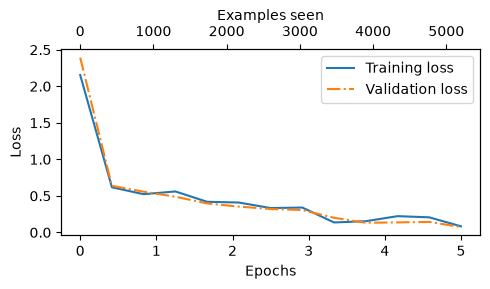

In [147]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

- 从上图的下降趋势可以看到，模型学习得不错。
- 此外，training loss 和 validation loss 非常接近，说明模型不太倾向于 overfit training data。
- 类似地，下面也可以绘制 accuracy。

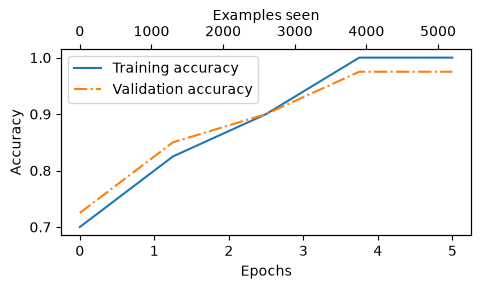

In [148]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

- 从上面的 accuracy plot 可以看到，模型在第 4 和第 5 个 epochs 后达到了相对较高的 training 和 validation accuracy。
- 但是，需要记住我们之前在 training function 中指定了 `eval_iter=5`，也就是说这里只估计了 training set 和 validation set 的性能。
- 可以按下面方式在完整 dataset 上计算 training、validation 和 test set performances。

In [149]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 97.21%
Validation accuracy: 97.32%
Test accuracy: 95.67%


- 可以看到，training 和 validation set performances 几乎相同。
- 不过，test set performance 略低，这说明模型对 training data 有非常轻微的 overfitting；同时，因为 validation data 用于调整一些 hyperparameters（例如 learning rate），它也对 validation data 有轻微适配。
- 这很正常；如果想进一步缩小这个差距，可以提高模型的 dropout rate（`drop_rate`），或者提高 optimizer 设置中的 `weight_decay`。

&nbsp;
### 6.8 将 LLM 用作垃圾短信分类器（Using the LLM as a spam classifier）

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch06_compressed/18.webp" width=500px>

- 最后，实际使用 finetuned GPT model。
- 下面的 `classify_review` function 实现的数据预处理步骤类似于前面实现的 `SpamDataset`。
- 然后，该函数返回模型预测的整数类别标签，并返回对应的类别名称。

In [128]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

- 下面用几个示例试一下。

In [150]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [151]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


- 最后，保存模型，以便之后复用时不必重新训练。

In [152]:
torch.save(model.state_dict(), "review_classifier.pth")

- 然后，在新的 session 中，可以按如下方式加载模型。

In [153]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)

<All keys matched successfully>

&nbsp;
## 总结和要点（Summary and takeaways）

- 参见 [./gpt_class_finetune.py](./gpt_class_finetune.py) 脚本；它是一个用于 classification finetuning 的 self-contained script。
- 练习答案可以在 [./exercise-solutions.ipynb](./exercise-solutions.ipynb) 中找到。
- 此外，感兴趣的读者可以在 [appendix E](../../appendix-E) 中找到关于 low-rank adaptation（LoRA）这种 parameter-efficient training 的介绍。